# 17_机器学习模型评估方法-交叉验证

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们介绍一下模型评估方法中最重要的一个概念：**交叉验证**\~

交叉验证（Cross Validation）是一种用来评估机器学习模型好不好的方法。它的主要目标是更公平、全面地测试模型在没见过的数据上的表现。

#### 为什么要交叉验证？

当你训练了一个模型，你当然希望它不仅在训练数据上表现好，还能在**新数据**上也表现好（泛化能力强）。

如果你只在训练数据上测试，那就像是“学生做自己写的题目”，成绩当然高，但不代表真的学懂。

再举一个生活中的例子：

当年的你正在准备一场考试，你有一本练习题本（数据集）。你不能只做前几页就说“我准备好了”。

而一个更合理的做法是：

- 把题本分成几份（比如5份）；
- 每次拿其中一份做测试题（当作“考试”），其他几份用来练习（训练模型）；
- 重复5次，每一份轮流当“考试题”；
- 看看你在每一份考试中的平均表现，这样才能知道你是否真正掌握了。

这就是交叉验证的核心思想。

#### 举个例子：

假设你有 100 个样本。你决定用 **5 折交叉验证（5-fold cross validation）**：

1. 把 100 个样本分成 5 份（每份 20 个样本）；
2. 第一次：用第1份做测试，其它4份做训练；
3. 第二次：用第2份做测试，其它4份做训练；
4. 依此类推共做5次；
5. 最后把这5次测试的结果（比如准确率）**平均一下**，这个平均值就是你对模型的最终评估。

## 核心原理

### 基本符号定义

- 数据集：$D = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$
- 模型训练函数：$f = \text{Train}(D_{\text{train}})$
- 模型性能度量函数（比如准确率、MSE等）：$L(f, D_{\text{test}})$
- K折交叉验证：将数据分成 $K$ 份，记为 $D_1, D_2, \dots, D_K$

### 数学表达（K折交叉验证）：

**Step 1：划分数据集**

将数据集 $D$ 均匀划分为 $K$ 个子集 $D_1, D_2, \dots, D_K$，要求这些子集两两不相交，且并集为原始数据集。


$$
D = \bigcup_{k=1}^{K} D_k,\quad D_i \cap D_j = \emptyset\ (i \ne j)
$$


**Step 2：进行K轮训练与测试**

对于每一个 $k \in \{1, 2, \dots, K\}$：

- **训练集**：其余 $K-1$ 个子集的并集，即：


$$
D_{\text{train}}^{(k)} = D \setminus D_k
$$


- **验证集（测试集）**：第 $k$ 个子集 $D_k$
- **训练模型**：使用 $D_{\text{train}}^{(k)}$ 得到模型 $f^{(k)}$
- **计算第 k 次验证的损失或准确率**：


$$
L_k = L(f^{(k)}, D_k)
$$


**Step 3：计算平均性能（整体交叉验证得分）**


$$
\text{CV}(f) = \frac{1}{K} \sum_{k=1}^{K} L_k
$$


这个平均得分 $\text{CV}(f)$ 就是我们评价这个模型的指标。

## 交叉验证的算法流程

以下是一个非常细化的算法流程（以 K 折交叉验证为例）：

**输入：**

- 数据集 $D$
- 折数 $K$
- 模型训练方法（比如逻辑回归、决策树等）
- 性能度量函数 $L$

**算法步骤：**

1. **随机打乱**数据集 $D$，避免原始数据有顺序偏差；
2. 将数据集划分为大小尽量相同的 $K$ 个子集：$D_1, D_2, ..., D_K$
3. 初始化性能记录列表：$\text{Scores} = []$
4. 对于 $k = 1$ 到 $K$ 做：

   - 设 $D_{\text{test}} = D_k$
   - 设 $D_{\text{train}} = D \setminus D_k$
   - 用 $D_{\text{train}}$ 训练模型，得到 $f^{(k)}$
   - 在 $D_{\text{test}}$ 上评估性能 $L_k = L(f^{(k)}, D_k)$
   - 将 $L_k$ 加入到 $\text{Scores}$
5. 最终结果：计算 $\text{Scores}$ 的平均值作为最终模型评估得分

**输出：**


$$
\text{CV}_{\text{score}} = \frac{1}{K} \sum_{k=1}^{K} L_k
$$


## 交叉验证的变体

1. **K折交叉验证**（最常见）
2. **留一交叉验证（LOOCV）**：每次只留一个样本做测试，其余样本训练，重复 $n$ 次
3. **分层K折交叉验证**：确保每折中各类样本比例一致（分类任务中常用）
4. **重复K折交叉验证**：对K折交叉验证重复多次，取平均，更稳定

总结一句话就是，交叉验证就是“把数据分成几份轮流训练测试，然后取平均表现”，它能让我们更可靠地评估模型的“真实水平”。

## 完整案例

我们以乳腺癌预测为实际案例，利用交叉验证来实践一下\~

我们使用 `sklearn.datasets` 提供的乳腺癌诊断数据集（`load_breast_cancer()`），其中包含30个数值型特征（如肿瘤大小、质地等），目标是预测肿瘤是否为良性（0）或恶性（1）。

### 完整代码

#### 1. 导入依赖库和数据加载

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

数据已经归一化，无需预处理。

#### 2. 构建模型与交叉验证流程

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

clf = RandomForestClassifier(random_state=42, n_estimators=100)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

- `StratifiedKFold` 确保每折中各类别比例一致（非常适用于分类问题）。
- `cross_val_score` 进行模型训练与评分（这里我们用准确率 `accuracy`）。

#### 3. 可视化交叉验证结果

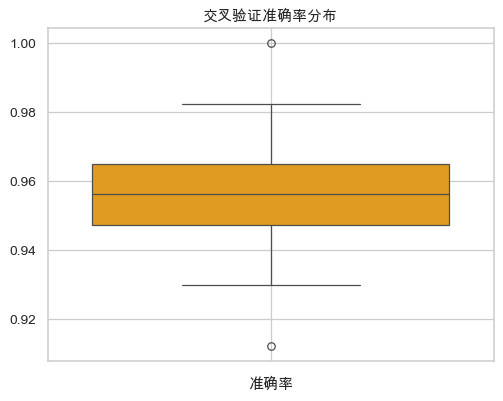

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="bright")

plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.figure()
sns.boxplot(cv_scores, color='orange')
plt.title("交叉验证准确率分布")
plt.xlabel("准确率")
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

使用 `seaborn` 的 boxplot 显示 10 折交叉验证得分分布，强调分布形状，识别异常值或偏态问题。

#### 4. 训练整体模型并评估混淆矩阵

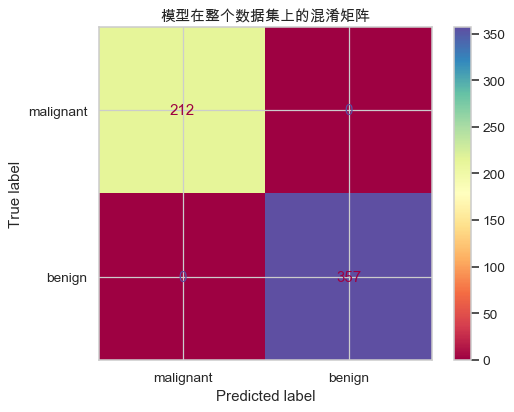

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf.fit(X, y)
y_pred = clf.predict(X)
cm = confusion_matrix(y, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Spectral")
plt.title("模型在整个数据集上的混淆矩阵")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

虽然整体训练评估容易造成过拟合，但可辅助验证模型是否明显失衡或误分。

#### 5. 输出评估结果

In [6]:
cv_scores.mean(), cv_scores.std()

(np.float64(0.956140350877193), np.float64(0.023862228962693768))

**平均准确率为：0.9561，标准差为：0.0238**

意味着模型在不同数据划分下性能稳定，泛化能力较强。

## 交叉验证优缺点分析

**优点：**

1. **更稳健的性能评估**：比单次划分更不易受到数据偏态影响；
2. **避免过拟合的幻觉**：防止因“好运气”划分带来的虚高准确率；
3. **适用于小数据集**：能最大化利用数据；
4. **支持不同评分函数**：灵活选用 F1、ROC AUC 等指标；

**缺点：**

1. **计算成本高**：对大型数据和复杂模型来说，运行10折就相当于训练模型10次；
2. **代码复杂度提升**：需要显式构造验证流程；
3. **模型无法直接用于生产部署**：训练过程中使用的是不同的数据子集，最终部署需重新训练。

### 与其他评估方法的对比

| 方法 | 是否支持泛化误差评估 | 数据使用率 | 适合场景 | 易实现性 | 稳定性 |
|-|-|-|-|-|-|
| 留出法（Holdout） | 一般 | 较低 | 数据量大、训练快速场景 | 高 | 不稳定 |
| K折交叉验证 | 是 | 高 | 小数据集、模型调参 | 中 | 稳定 |
| 留一法（LOOCV） | 是 | 非常高 | 非常小的数据集 | 低 | 非常稳定 |
| 自助法（Bootstrap） | 是 | 可调节 | 数据偏斜、统计推断 | 中等 | 中等 |

### 何时使用交叉验证？

**优选场景：**

- 数据量不大（如数百至几千样本）；
- 高度关注泛化误差；
- 模型选择、调参（如网格搜索）；
- 类别样本分布不均时使用 StratifiedKFold 更优。

**可考虑其他方法的情况：**

- 大规模数据训练场景（可采用留出法 + 多次平均）；
- 模型训练开销极高（如深度神经网络）；
- 需要快速实验（可先用 Holdout 快速验证）；

## 总结

交叉验证，尤其是常用的 **K 折交叉验证**，是机器学习中评估模型最可靠、最广泛使用的方法之一。尽管交叉验证的代价是训练时间加倍，但在模型泛化能力评估方面，它几乎是不可或缺的。